In [ ]:
%pip install -q rasterio geopandas torch torchvision numpy scikit-image matplotlib tqdm

In [ ]:
# Only required with Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os
import glob
import numpy as np
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import torch
from torch.utils.data import Dataset, DataLoader
import string

# Dataset

In [3]:
#@title Constants
BANDS = [1, 2, 3, 4, 5]   # Blue, Green, Red, RedEdge, NIR

In [4]:
#@title Inputs
MULTISPEC_IMAGE_PATH = "../dataset/0_V2/0_V2/SET" # @param {type:"string"}
BOYTRIS_CLUSTERS_SHP   = "../dataset/Botrytis_clusters/Botrytis_clusters.shp" # @param {type:"string"}
GCP_SHP = "../dataset/GCPs/GCPs.shp" # @param {type:"string"}
TRUNK_LOCATIONS_SHP = "../dataset/Trunk_locations/Trunks.shp" # @param {type:"string"}
OUTPUT_DIR = "../repos/self-supervised-rosette-weed-detection/output/" # @param {type:"string"}

In [5]:
#@title parameters
PATCH_SIZE = 128 # @param {type:"number"}
VAL_SPLIT = 0.2

In [6]:
# # Optional GPU support
# try:
#     import cupy as cp
#     xp = cp
#     GPU_AVAILABLE = True
#     print("✅ Using GPU via CuPy")
# except ImportError:
#     xp = np
#     GPU_AVAILABLE = False
#     print("⚠️ CuPy not available, using CPU NumPy")

In [10]:
from rasterio.transform import from_gcps
from rasterio.control import GroundControlPoint

def get_transform_from_gcps(gcp_shp_path):
    gcps_gdf = gpd.read_file(gcp_shp_path)
    print(f"GCP shapefile columns: {gcps_gdf.columns.tolist()}") # Print columns for debugging
    gcps = []
    for _, row in gcps_gdf.iterrows():
        # Assuming columns 0 and 1 are X and Y. **VERIFY THIS based on the print output.**
        # Adjust the column indices [0] and [1] if X and Y are in different columns.
        gcps.append(
            GroundControlPoint(
                row=row[1],
                col=row[0],
                x=row.geometry.x,
                y=row.geometry.y
            )
        )
    return from_gcps(gcps), gpd.read_file(gcp_shp_path).crs

def load_multispectral_image(path, gcp_shp_path=None):
    """Load and stack single-band TIFFs into a multi-band image."""
    band_paths = [f"{path}_{b}.tif" for b in BANDS]
    bands = []
    meta = None
    transform, crs = None, None

    if gcp_shp_path and os.path.exists(gcp_shp_path):
        transform, crs = get_transform_from_gcps(gcp_shp_path)


    for i, path in enumerate(band_paths):
        with rasterio.open(path) as src:
            if meta is None:
                meta = src.meta.copy()
                if meta.get('crs') is None and crs is not None:
                    meta['crs'] = crs # Use CRS from GCPs if raster has no CRS
                if meta.get('transform') is None and transform is not None:
                    meta['transform'] = transform # Use transform from GCPs if raster has no transform

            band = src.read(1).astype(np.float32)
            # if GPU_AVAILABLE:
            #     band = xp.asarray(band) # Convert to CuPy array
            bands.append(band)


    stacked = np.stack(bands, axis=0)
    return stacked, meta

# Vegetation indices
def compute_ndvi(stacked):
    """Compute NDVI from multispectral bands (assumes RedEdge sensor order)."""
    nir = stacked[3]
    red = stacked[2]
    ndvi = (nir - red) / (nir + red + 1e-6)
    return np.clip(ndvi, -1, 1)

def compute_ndre(stacked):
    red_edge = stacked[3]
    nir = stacked[4]
    ndre = (nir - red_edge) / (nir + red_edge + 1e-6)
    return np.clip(ndre, -1, 1)


# Align shapefiles
def load_and_align_shapefile(path, reference_meta):
    """Reproject shapefile to the raster CRS."""
    gdf = gpd.read_file(path)
    if gdf.crs != reference_meta['crs']:
        gdf = gdf.to_crs(reference_meta['crs'])
    return gdf

def rasterize_shapes(shapefile, reference_raster):
    """Rasterizes shapefile polygons to match raster grid."""
    import rasterio.features
    with rasterio.open(reference_raster) as src:
        meta = src.meta.copy()
        transform = src.transform
        out_shape = (src.height, src.width)

    gdf = gpd.read_file(shapefile).to_crs(meta['crs'])
    mask = rasterio.features.rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=out_shape,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype=np.uint8
    )
    return mask

# Patch extraction
def extract_patches(image, patch_size=PATCH_SIZE):
    patches = []
    h, w = image.shape[1], image.shape[2]
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            patch = image[:, y:y+patch_size, x:x+patch_size]
            if patch.shape[1] == patch_size and patch.shape[2] == patch_size:
                patches.append(patch)
    return np.stack(patches)

In [11]:
#@title Dataset Class - (lazy dataset (memory-mapped))
from rasterio.windows import Window
class VineyardDataset(Dataset):
    def __init__(self, data_dir, shapefiles, patch_size=128, stride=128, bands=[1,2,3,4,5], gcp_shp_path=None):
        """
        data_dir: folder with multispectral files named <filename>_<band>.tiff
        shapefiles: dict with keys like {'botrytis': path, 'trunk': path}
        gcp_shp_path: path to the GCP shapefile
        """
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.stride = stride
        self.bands = bands # Store all bands to load
        self.gcp_shp_path = gcp_shp_path

        # List all unique image prefixes (assuming filenames like vineyard_001_1.tif)
        self.prefixes = sorted(list(set(["_".join(os.path.basename(f).split("_")[:-1])
                                         for f in glob.glob(os.path.join(data_dir, "*.tif"))])))
        self.shapefiles = shapefiles

        # Pre-load and align shapefiles and get metadata from one sample image
        self.reference_meta = None
        self._loaded_shapefiles = {}

        if self.prefixes:
            # Load meta from the first image (using the first band) to use as reference
            first_image_base_path = os.path.join(self.data_dir, self.prefixes[0])
            stacked, self.reference_meta = load_multispectral_image(first_image_base_path, self.gcp_shp_path)
            print(f"Reference metadata CRS: {self.reference_meta.get('crs')}")


            # Load and align all shapefiles to the reference CRS
            for key, shp_path in self.shapefiles.items():
                try:
                    self._loaded_shapefiles[key] = load_and_align_shapefile(shp_path, self.reference_meta)
                    print(f"Loaded and aligned shapefile '{key}' to CRS: {self._loaded_shapefiles[key].crs}")
                except Exception as e:
                    print(f"Error loading or aligning shapefile {shp_path}: {e}")
                    self._loaded_shapefiles[key] = None # Mark as failed or handle as appropriate


        # Index patches by (prefix, x, y)
        self.index = []
        if self.prefixes and self.reference_meta and self.reference_meta.get('width') is not None and self.reference_meta.get('height') is not None:
            w, h = self.reference_meta['width'], self.reference_meta['height']
            for prefix in self.prefixes:
                # You might want to verify each image has the same dimensions as the reference image
                # For simplicity now, we assume they do.
                for i in range(0, h - self.patch_size + 1, self.stride):
                    for j in range(0, w - self.patch_size + 1, self.stride):
                        self.index.append((prefix, j, i))
        else:
            print("Could not build patch index. Check image files and reference metadata.")


    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        prefix, x, y = self.index[idx]
        imgs_all_bands = [] # Store all loaded bands initially
        # Load bands for the current image prefix and patch
        for b in self.bands:
            band_path = os.path.join(self.data_dir, f"{prefix}_{b}.tif")
            try:
                with rasterio.open(band_path) as src:
                    # Use the window to read only the patch area
                    window = Window(x, y, self.patch_size, self.patch_size)
                    img = src.read(1, window=window).astype(np.float32)
                    # Basic normalization per band (0-1)
                    min_val = np.min(img)
                    max_val = np.max(img)
                    if (max_val - min_val) > 1e-8: # Avoid division by zero for constant patches
                         img = (img - min_val) / (max_val - min_val)
                    else:
                         img = np.zeros_like(img) # Or handle as appropriate for flat patches

                    imgs_all_bands.append(img)
            except Exception as e:
                print(f"Error reading band {b} for {prefix} at patch ({x},{y}): {e}")
                # Decide how to handle read errors - return empty, raise error, etc.
                # Raising might be better for debugging data issues.
                raise


        if not imgs_all_bands or len(imgs_all_bands) != len(self.bands):
             raise RuntimeError(f"Failed to load all bands for {prefix} at patch ({x},{y})")

        # --- Select only RGB bands for the model input ---
        # Assuming bands 1, 2, 3 correspond to the first three loaded bands (indices 0, 1, 2)
        # Need to ensure self.bands is ordered correctly [1, 2, 3, ...]
        rgb_bands = imgs_all_bands[:3] # Select first 3 bands for RGB input
        img_input = np.stack(rgb_bands, axis=0) # [C=3, H, W]

        # Rasterize masks for the current patch using the pre-loaded/aligned GeoDataFrames
        masks = {}
        for key, gdf in self._loaded_shapefiles.items():
            if gdf is not None: # Only process if shapefile loaded successfully
                 # Rasterize the full GeoDataFrame first
                 full_mask = rasterize_shapes(gdf, self.reference_meta)
                 # Extract the patch from the full mask
                 mask_patch = full_mask[y:y+self.patch_size, x:x+self.patch_size]
                 masks[key] = mask_patch
            else:
                 # If shapefile failed to load, provide a zero mask for this type
                 masks[key] = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)


        # Combine masks: 0 = background, 1 = Botrytis, 2 = trunk
        # Ensure masks are present
        botrytis_mask = masks.get('botrytis', np.zeros((self.patch_size, self.patch_size), dtype=np.uint8))
        trunk_mask = masks.get('trunks', np.zeros((self.patch_size, self.patch_size), dtype=np.uint8))

        # Ensure masks are 2D before combining
        if botrytis_mask.ndim == 3: botrytis_mask = botrytis_mask.squeeze(0)
        if trunk_mask.ndim == 3: trunk_mask = trunk_mask.squeeze(0)


        combined_mask = np.maximum(botrytis_mask, trunk_mask * 2)
        combined_mask = combined_mask[np.newaxis, :, :] # Add channel dimension for consistency with other data


        # Create target layer: NDVI (can be used as multi-channel supervision)
        # Compute NDVI for the current patch using the necessary bands from imgs_all_bands
        # Assuming band 4 (NIR) is at index 3 and band 3 (Red) is at index 2 in imgs_all_bands
        if len(imgs_all_bands) >= 4: # Check if NIR and Red bands were loaded
            nir_patch = imgs_all_bands[3] # Band 4 (NIR) is at index 3 in the list
            red_patch = imgs_all_bands[2] # Band 3 (Red) is at index 2 in the list
            # Avoid division by zero
            denominator_patch = nir_patch + red_patch + 1e-8
            ndvi_patch = (nir_patch - red_patch) / denominator_patch
            ndvi_patch = np.clip(ndvi_patch, -1.0, 1.0)
        else:
             print(f"Warning: Not enough bands ({len(imgs_all_bands)}) loaded to compute NDVI. Returning zeros for target.")
             ndvi_patch = np.zeros((self.patch_size, self.patch_size), dtype=np.float32)


        target = np.expand_dims(ndvi_patch, axis=0) # Add channel dimension

        return {
            'image': torch.from_numpy(img_input).float(), # Use the stacked RGB bands
            'target': torch.from_numpy(target).float(),
            'mask': torch.from_numpy(combined_mask).long(), # Use long for masks
            'prefix': prefix,
            'coord': (x, y)
        }

In [12]:
BATCH_SIZE = 32
NUM_WORKERS = 0 # Changed to 0 for debugging multiprocessing issue
STRIDE=128
PIN_MEMORY = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True   # automatic mixed precision
CACHE_IN_MEMORY = False  # set True if you have enough RAM and want faster I/O

In [13]:
from torch.utils.data import DataLoader, random_split
def get_dataloaders(
    batch_size=BATCH_SIZE,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    num_workers=NUM_WORKERS,
    train_split=0.7,
    val_split=VAL_SPLIT
):
    shapefiles = {
      "botrytis": BOYTRIS_CLUSTERS_SHP,
      "trunks": TRUNK_LOCATIONS_SHP
    }
    dataset = VineyardDataset(
        data_dir=MULTISPEC_IMAGE_PATH,
        shapefiles=shapefiles,
        patch_size=patch_size,
        stride=stride
    )

    total_len = len(dataset)
    train_len = int(total_len * train_split)
    val_len = int(total_len * val_split)
    test_len = total_len - train_len - val_len

    train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

    dataloaders = {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True),
        'val': DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True),
        'test': DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True),
    }

    return dataloaders

loader = get_dataloaders(num_workers=2,val_split=VAL_SPLIT)
if loader is None:
    print("Failed to create dataloaders. Aborting training.")
else:
    print(f"Device: {DEVICE.type}; Train loader batches: {len(loader['train']) if loader['train'] is not None else 0}")

/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Reference metadata CRS: None
Error loading or aligning shapefile ../dataset/Botrytis_clusters/Botrytis_clusters.shp: Must pass either crs or epsg.
Error loading or aligning shapefile ../dataset/Trunk_locations/Trunks.shp: Must pass either crs or epsg.
Device: cuda; Train loader batches: 806


# Evaluation

In [ ]:
from pathlib import Path

ck_file = Path(OUTPUT_DIR,"checkpoints/20251101-arc_nca-best.pth")
# best_ck_files = list(ck_dir.glob("arc_nca-*-e_*.pth
print(f"Loading checkpoint: {ck_file}")
try:
    # load_checkpoint(path, model, optimizer=None, map_location=None)
    load_checkpoint(str(ck_file), model, optimizer=None, map_location=DEVICE)
    model.to(DEVICE)
    model.eval()
    print("Checkpoint loaded, model set to eval()")
except Exception as e:
    print(f"Failed to load checkpoint {ck_file}: {e}")

# Get a random test tile
test_dataset = loader['test'].dataset
sample = test_dataset[np.random.randint(len(test_dataset))]

# Support dict samples (from our VineyardDataset) or tuple/list samples
if isinstance(sample, dict):
    rgb_img = sample['image']        # [C,H,W]
    real_ndvi = sample['target']
elif isinstance(sample, (tuple, list)) and len(sample) >= 2:
    rgb_img, real_ndvi = sample[0], sample[1]
else:
    raise RuntimeError("Unexpected sample format from dataset")

# Ensure batch dimension and move to device
if rgb_img.dim() == 3:
    rgb_img = rgb_img.unsqueeze(0)  # [1,C,H,W]
rgb_img = rgb_img.to(DEVICE)

# Convert target to numpy for visualization/metrics
if isinstance(real_ndvi, torch.Tensor):
    real_ndvi = real_ndvi.cpu().numpy().squeeze()
else:
    real_ndvi = np.array(real_ndvi).squeeze()

with torch.no_grad():
    final_state = model(rgb_img, steps=32)
    pred_ndvi = model.predict_ndvi(final_state).cpu().numpy().squeeze()


Loading checkpoint: /home/adri/UOC/TFM/repos/self-supervised-rosette-weed-detection/output/checkpoints/arc_nca_best.pth
Checkpoint loaded, model set to eval()
Initial state shape in forward: torch.Size([1, 21, 128, 128]), expected channels: 21


/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
# Flatten arrays for metrics
r2 = r2_score(real_ndvi.flatten(), pred_ndvi.flatten())
rmse = np.sqrt(mean_squared_error(real_ndvi.flatten(), pred_ndvi.flatten()))
print(f"R² = {r2:.4f} | RMSE = {rmse:.4f}")

R² = 0.5372 | RMSE = 0.3225


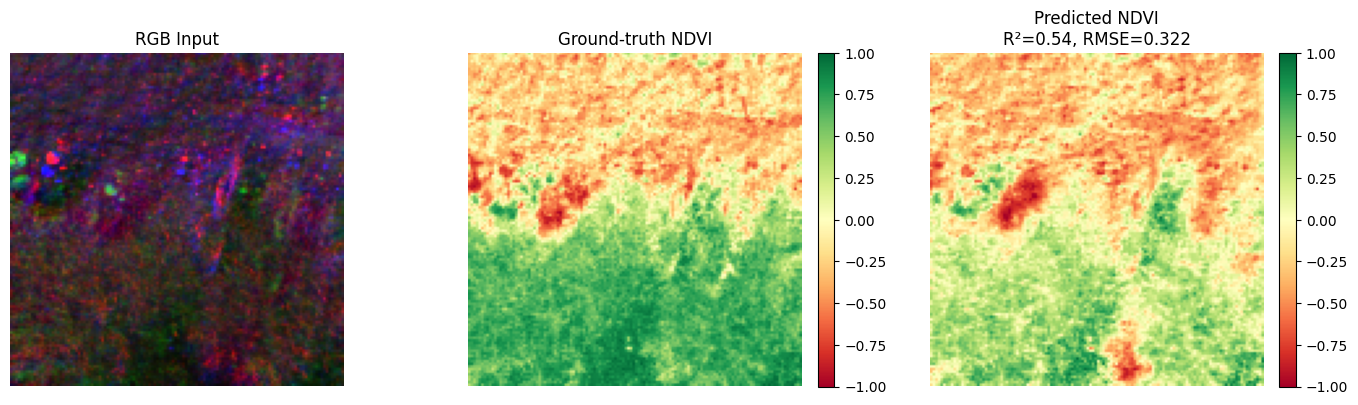

In [ ]:
import matplotlib.pyplot as plt
def show_ndvi_comparison(rgb, ndvi_true, ndvi_pred, cmap="RdYlGn"):
    plt.figure(figsize=(14, 4))
    
    # RGB
    plt.subplot(1, 3, 1)
    plt.imshow(np.clip(np.moveaxis(rgb.cpu().numpy(), 0, -1), 0, 1))
    plt.title("RGB Input")
    plt.axis("off")

    # True NDVI
    plt.subplot(1, 3, 2)
    plt.imshow(ndvi_true, cmap=cmap, vmin=-1, vmax=1)
    plt.title("Ground-truth NDVI")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    # Predicted NDVI + Residual
    plt.subplot(1, 3, 3)
    plt.imshow(ndvi_pred, cmap=cmap, vmin=-1, vmax=1)
    # plt.title(f"Predicted NDVI\nR²={r2:.2f}, RMSE={rmse:.3f}")
    plt.title(f"Predicted NDVI")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ndvi_comparison(rgb_img[0], real_ndvi, pred_ndvi)


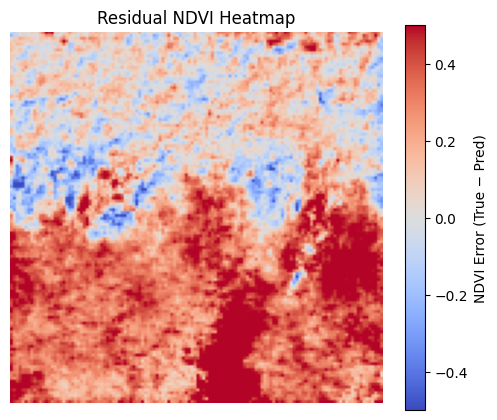

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(real_ndvi - pred_ndvi, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.colorbar(label="NDVI Error (True − Pred)")
plt.title("Residual NDVI Heatmap")
plt.axis("off")
plt.show()


In [ ]:
r2_list, rmse_list = [], []
for i in range(len(test_dataset)):
    rgb, ndvi_true = test_dataset[i]
    rgb = rgb.unsqueeze(0).to(DEVICE)
    ndvi_true = ndvi_true.numpy().squeeze()

    with torch.no_grad():
        ndvi_pred = model.predict_ndvi(model(rgb, steps=32)).cpu().numpy().squeeze()

    r2_list.append(r2_score(ndvi_true.flatten(), ndvi_pred.flatten()))
    rmse_list.append(np.sqrt(mean_squared_error(ndvi_true.flatten(), ndvi_pred.flatten())))

print(f"Mean R² = {np.mean(r2_list):.4f}, Mean RMSE = {np.mean(rmse_list):.4f}")

/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


ValueError: too many values to unpack (expected 2)

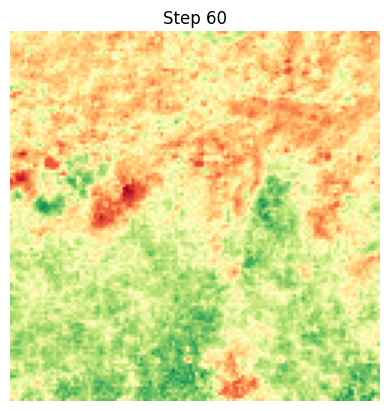

In [ ]:
from IPython.display import clear_output
import time

state = torch.cat([
    rgb_img,
    torch.zeros((1, model.hidden, *rgb_img.shape[2:]), device=DEVICE),
    torch.zeros((1, model.out, *rgb_img.shape[2:]), device=DEVICE),
    torch.ones((1, 1, *rgb_img.shape[2:]), device=DEVICE)
], dim=1)

for step in range(0, 64, 4):
    with torch.no_grad():
        state = model.step(state)
    pred = model.predict_ndvi(state).cpu().numpy().squeeze()
    clear_output(wait=True)
    plt.imshow(pred, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.title(f"Step {step}")
    plt.axis("off")
    plt.show()
    time.sleep(0.2)